In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

sns.set_theme(style="whitegrid")

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DATA_DIR = DATA_DIR / "processed"

REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

<h2>Load Sales Data</h2>

In [3]:
DATA_PATH = (
    PROCESSED_DATA_DIR /
    "online_retail_cleaned.csv"
)

df = pd.read_csv(
    DATA_PATH,
    parse_dates=["InvoiceDate"]
)

print(f"Sales rows: {len(df):,}")

Sales rows: 1,010,535


<h2>Load Returns</h2>

In [4]:
RETURNS_PATH = (
    PROCESSED_DATA_DIR /
    "online_retail_returns.csv"
)

returns_df = pd.read_csv(
    RETURNS_PATH,
    parse_dates=["InvoiceDate"]
)

print(f"Return rows: {len(returns_df):,}")

Return rows: 22,496


<h2>Create Product-Level Dataset</h2>

In [5]:
product_analysis = (
    df.groupby(
        [
            "StockCode",
            "DescriptionClean"
        ]
    )
    .agg(
        Revenue=("TotalPrice", "sum"),
        UnitsSold=("Quantity", "sum"),
        Orders=("Invoice", "nunique"),
        Customers=("CustomerID", "nunique"),
        AvgUnitPrice=("UnitPrice", "mean")
    )
    .reset_index()
)

product_analysis.head()

,StockCode,DescriptionClean,Revenue,UnitsSold,Orders,Customers,AvgUnitPrice
0,10002,INFLATABLE POLITICAL GLOBE,"6,942.26",8671,362,164,0.98
1,10002R,ROBOT PENCIL SHARPNER,20.57,4,3,0,5.13
2,10080,CHECK,0.00,22,1,0,0.00
3,10080,GROOVY CACTUS INFLATABLE,129.29,315,27,23,0.51
4,10109,BENDY COLOUR PENCILS,1.68,4,1,1,0.42


<h2>Product-Level Revenue Ranking</h2>

In [6]:
top_revenue_products = (
    product_analysis
    .sort_values(
        "Revenue",
        ascending=False
    )
)

top_revenue_products.head(20)

,StockCode,DescriptionClean,Revenue,UnitsSold,Orders,Customers,AvgUnitPrice
5773,M,MANUAL,"339,599.81",9637,791,443,391.06
1948,22423,REGENCY CAKESTAND 3 TIER,"330,590.32",26495,3920,1314,14.18
5772,DOT,DOTCOM POSTAGE,"309,854.11",1420,1420,1,218.21
5150,85123A,WHITE HANGING HEART T-LIGHT HOLDER,"257,546.20",94147,5361,1490,3.07
3459,23843,"PAPER CRAFT , LITTLE BIRDIE","168,469.60",80995,1,1,2.08
3833,47566,PARTY BUNTING,"148,318.28",28217,2676,894,5.71
5117,85099B,JUMBO BAG RED RETROSPOT,"145,961.83",77286,3249,860,2.36
4777,84879,ASSORTED COLOUR BIRD ORNAMENT,"129,324.49",80090,2808,1010,1.86
5775,POST,POSTAGE,"125,682.42",5363,1851,405,29.47
1525,22086,PAPER CHAIN KIT 50'S CHRISTMAS,"117,760.29",35084,2018,896,3.37


<h2>Top 20 Products by Revenue</h2>

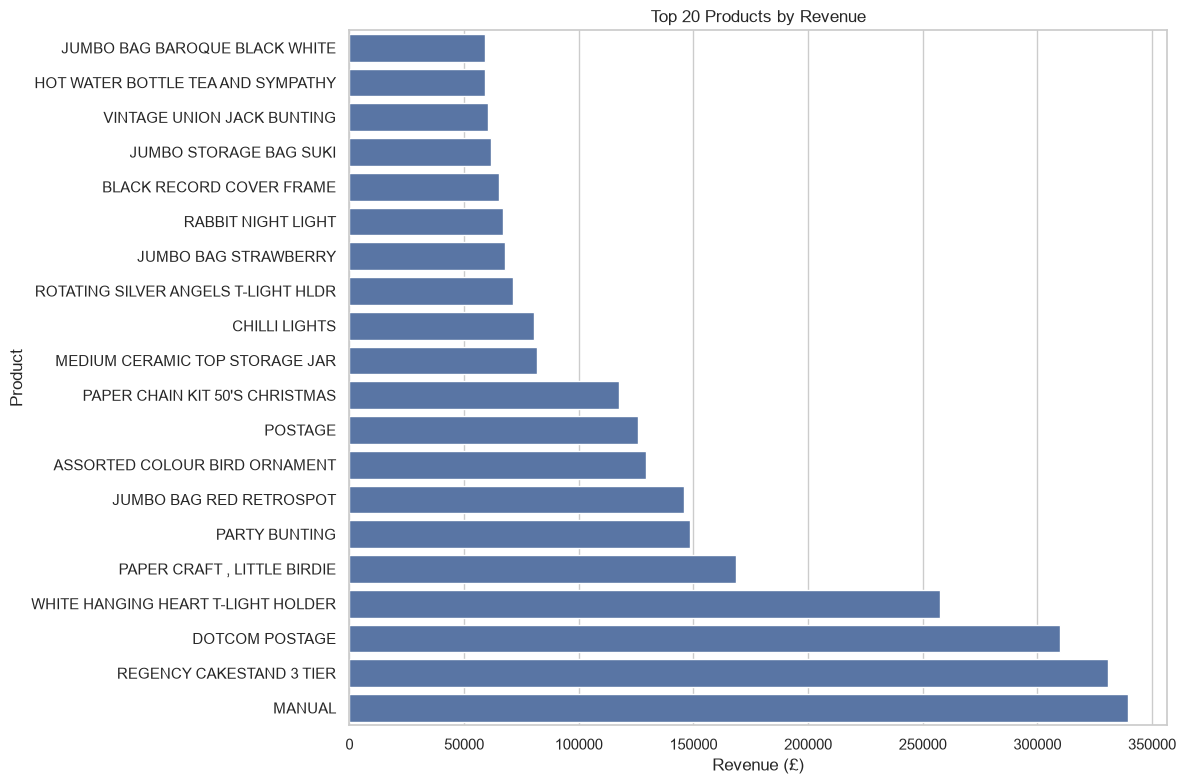

In [7]:
top20_revenue = (
    top_revenue_products
    .head(20)
    .sort_values("Revenue")
)

plt.figure(figsize=(12, 8))

sns.barplot(
    data=top20_revenue,
    x="Revenue",
    y="DescriptionClean"
)

plt.title("Top 20 Products by Revenue")
plt.xlabel("Revenue (£)")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

<h2>Top Products by Volume</h2>

In [8]:
top_volume_products = (
    product_analysis
    .sort_values(
        "UnitsSold",
        ascending=False
    )
)

top_volume_products.head(20)

,StockCode,DescriptionClean,Revenue,UnitsSold,Orders,Customers,AvgUnitPrice
4302,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,"24,445.61",106250,1021,482,0.28
5150,85123A,WHITE HANGING HEART T-LIGHT HOLDER,"257,546.20",94147,5361,1490,3.07
3459,23843,"PAPER CRAFT , LITTLE BIRDIE","168,469.60",80995,1,1,2.08
4777,84879,ASSORTED COLOUR BIRD ORNAMENT,"129,324.49",80090,2808,1010,1.86
2904,23166,MEDIUM CERAMIC TOP STORAGE JAR,"81,700.92",78033,247,138,1.47
5117,85099B,JUMBO BAG RED RETROSPOT,"145,961.83",77286,3249,860,2.36
125,17003,BROCADE RING PURSE,"14,766.42",70379,457,215,0.30
1430,21977,PACK OF 60 PINK PAISLEY CAKE CASES,"28,081.73",56061,1993,767,0.71
4945,84991,60 TEATIME FAIRY CAKE CASES,"27,041.21",54028,2127,822,0.66
1661,22197,SMALL POPCORN HOLDER,"42,699.89",48597,1412,426,1.04


<h2>Top 20 by Volume</h2>

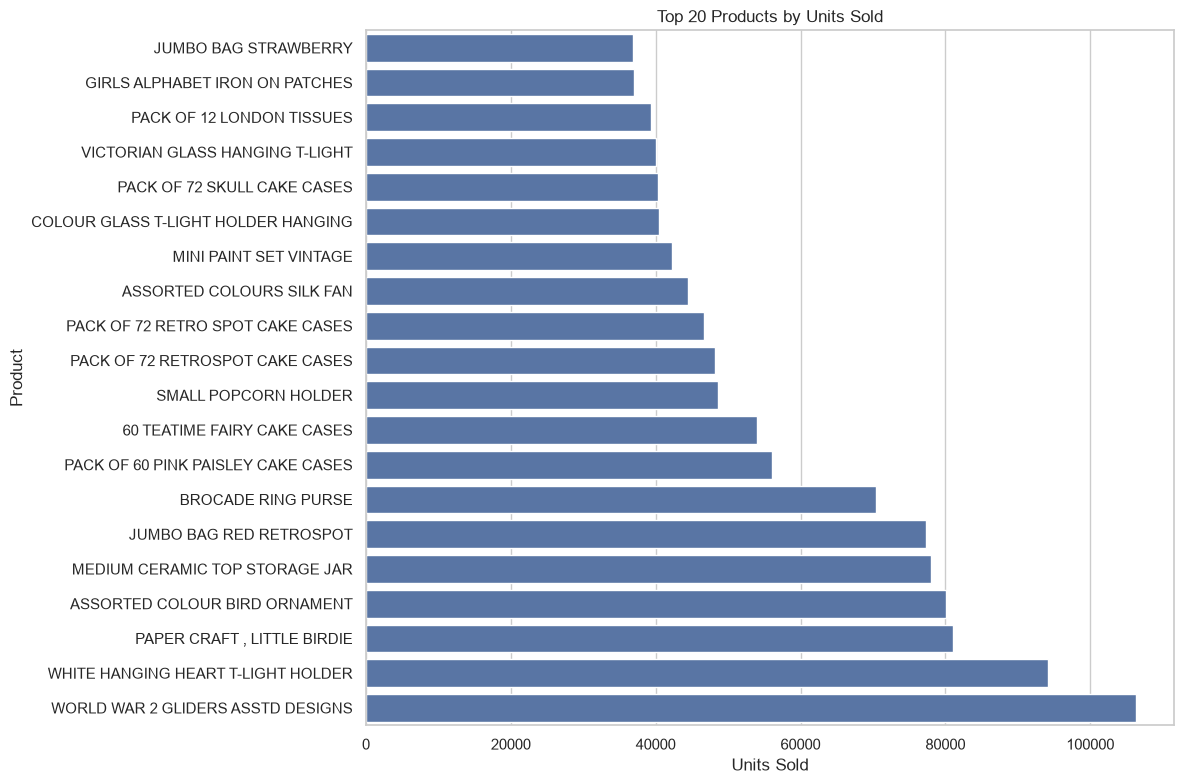

In [9]:
top20_volume = (
    top_volume_products
    .head(20)
    .sort_values("UnitsSold")
)

plt.figure(figsize=(12, 8))

sns.barplot(
    data=top20_volume,
    x="UnitsSold",
    y="DescriptionClean"
)

plt.title("Top 20 Products by Units Sold")
plt.xlabel("Units Sold")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

<h2>Revenue Rank vs Volume Rank</h2>

In [10]:
product_analysis["RevenueRank"] = (
    product_analysis["Revenue"]
    .rank(
        ascending=False,
        method="min"
    )
)

product_analysis["VolumeRank"] = (
    product_analysis["UnitsSold"]
    .rank(
        ascending=False,
        method="min"
    )
)

In [11]:
product_analysis["RankDifference"] = (
    product_analysis["VolumeRank"] -
    product_analysis["RevenueRank"]
)

<h2>Products Stronger by Revenue</h2>

In [12]:
revenue_strong_products = (
    product_analysis
    .sort_values(
        "RankDifference",
        ascending=False
    )
)

revenue_strong_products[
    [
        "DescriptionClean",
        "Revenue",
        "UnitsSold",
        "RevenueRank",
        "VolumeRank",
        "RankDifference"
    ]
].head(20)

,DescriptionClean,Revenue,UnitsSold,RevenueRank,VolumeRank,RankDifference
5749,AMAZON FEE,"20,467.80",3,197.00,"5,514.00","5,317.00"
5750,ADJUST BAD DEBT,"11,062.06",1,428.00,"5,647.00","5,219.00"
5747,ADJUSTMENT BY JOHN ON 26/01/2010 17,"6,563.50",16,719.00,"5,076.00","4,357.00"
2044,PICNIC BASKET WICKER 60 PIECES,"39,619.50",61,60.00,"4,410.00","4,350.00"
2229,VINTAGE BLUE KITCHEN CABINET,"9,290.00",45,521.00,"4,605.00","4,084.00"
2228,VINTAGE RED KITCHEN CABINET,"12,845.00",76,359.00,"4,281.00","3,922.00"
2449,RUSTIC SEVENTEEN DRAWER SIDEBOARD,"5,910.00",38,796.00,"4,694.00","3,898.00"
2447,LOVE SEAT ANTIQUE WHITE METAL,"6,210.00",58,760.00,"4,446.00","3,686.00"
2443,CHEST NATURAL WOOD 20 DRAWERS,"3,655.00",32,"1,215.00","4,775.00","3,560.00"
2450,REGENCY MIRROR WITH SHUTTERS,"2,565.00",17,"1,587.00","5,056.00","3,469.00"


<h2>Products Stronger by Volume</h2>

In [13]:
volume_strong_products = (
    product_analysis
    .sort_values(
        "RankDifference"
    )
)

volume_strong_products[
    [
        "DescriptionClean",
        "Revenue",
        "UnitsSold",
        "RevenueRank",
        "VolumeRank",
        "RankDifference"
    ]
].head(20)

,DescriptionClean,Revenue,UnitsSold,RevenueRank,VolumeRank,RankDifference
5148,?,0.00,4000,"5,593.00",687.00,"-4,906.00"
3120,CAME CODED AS 20713,0.00,3100,"5,593.00",884.00,"-4,709.00"
4938,?,0.00,3000,"5,593.00",904.00,"-4,689.00"
1372,?,0.00,1520,"5,593.00","1,613.00","-3,980.00"
3825,DID A CREDIT AND DID NOT TICK RET,0.00,1300,"5,593.00","1,774.00","-3,819.00"
3835,INCORRECTLY CREDITED C550456 SEE 47,0.00,1300,"5,593.00","1,774.00","-3,819.00"
804,?,0.00,1146,"5,593.00","1,914.00","-3,679.00"
58,POPART COL BALLPOINT PEN ASST,185.73,4313,"4,219.00",643.00,"-3,576.00"
288,WRONGLY CODED 23343,0.00,1000,"5,593.00","2,080.00","-3,513.00"
50,POPART WOODEN PENCILS ASST,429.44,9312,"3,610.00",255.00,"-3,355.00"


<h2>Average Revenue per Unit</h2>

In [14]:
product_analysis["RevenuePerUnit"] = (
    product_analysis["Revenue"] /
    product_analysis["UnitsSold"]
)

product_analysis[
    [
        "DescriptionClean",
        "Revenue",
        "UnitsSold",
        "RevenuePerUnit"
    ]
].head()

,DescriptionClean,Revenue,UnitsSold,RevenuePerUnit
0,INFLATABLE POLITICAL GLOBE,"6,942.26",8671,0.80
1,ROBOT PENCIL SHARPNER,20.57,4,5.14
2,CHECK,0.00,22,0.00
3,GROOVY CACTUS INFLATABLE,129.29,315,0.41
4,BENDY COLOUR PENCILS,1.68,4,0.42


<h2>High-Value Products</h2>

In [15]:
high_volume_products = product_analysis[
    product_analysis["UnitsSold"] >= 100
].copy()

high_value_products = (
    high_volume_products
    .sort_values(
        "RevenuePerUnit",
        ascending=False
    )
)

high_value_products[
    [
        "DescriptionClean",
        "UnitsSold",
        "Revenue",
        "RevenuePerUnit"
    ]
].head(20)

,DescriptionClean,UnitsSold,Revenue,RevenuePerUnit
5772,DOTCOM POSTAGE,1420,"309,854.11",218.21
1246,VINTAGE POST OFFICE CABINET,123,"7,954.87",64.67
5752,CARRIAGE,268,"13,426.00",50.10
4303,SET/4 WHITE RETRO STORAGE CUBES,1128,"43,844.96",38.87
358,FUSCHIA RETRO BAR STOOL,103,"3,672.35",35.65
359,BLACK RETRO BAR STOOL,100,"3,533.90",35.34
5773,MANUAL,9637,"339,599.81",35.24
2457,HALL CABINET WITH 3 DRAWERS,120,"4,163.54",34.70
357,RED RETRO BAR STOOL,107,"3,570.87",33.37
5775,POSTAGE,5363,"125,682.42",23.44


<h2>Low-Value High-Volume Products</h2>

In [16]:
low_value_high_volume = (
    high_volume_products
    .sort_values(
        "RevenuePerUnit"
    )
)

low_value_high_volume[
    [
        "DescriptionClean",
        "UnitsSold",
        "Revenue",
        "RevenuePerUnit"
    ]
].head(20)

,DescriptionClean,UnitsSold,Revenue,RevenuePerUnit
529,CHECKED,176,0.00,0.00
3687,TK MAXX MIX UP WITH PINK,180,0.00,0.00
1623,?,142,0.00,0.00
4820,EUROBARGAIN INVC/CREDIT,372,0.00,0.00
2656,MAILOUT,100,0.00,0.00
1094,RCVD BE AIR TEMP FIX FOR DOTCOM SIT,100,0.00,0.00
4839,FOUND,600,0.00,0.00
4852,?SOLD INDIVIDUALLY?,486,0.00,0.00
4938,?,3000,0.00,0.00
804,?,1146,0.00,0.00


<h2>Product Revenue Concentration</h2>

In [17]:
pareto_products = (
    product_analysis
    .sort_values(
        "Revenue",
        ascending=False
    )
    .reset_index(drop=True)
)

pareto_products["CumulativeRevenue"] = (
    pareto_products["Revenue"]
    .cumsum()
)

total_product_revenue = (
    pareto_products["Revenue"].sum()
)

pareto_products["CumulativeRevenuePct"] = (
    pareto_products["CumulativeRevenue"] /
    total_product_revenue *
    100
)

pareto_products["ProductPct"] = (
    np.arange(
        1,
        len(pareto_products) + 1
    ) /
    len(pareto_products) *
    100
)

pareto_products.head()

,StockCode,DescriptionClean,Revenue,UnitsSold,Orders,Customers,AvgUnitPrice,RevenueRank,VolumeRank,RankDifference,RevenuePerUnit,CumulativeRevenue,CumulativeRevenuePct,ProductPct
0,M,MANUAL,"339,599.81",9637,791,443,391.06,1.00,244.00,243.00,35.24,"339,599.81",1.66,0.02
1,22423,REGENCY CAKESTAND 3 TIER,"330,590.32",26495,3920,1314,14.18,2.00,43.00,41.00,12.48,"670,190.13",3.27,0.03
2,DOT,DOTCOM POSTAGE,"309,854.11",1420,1420,1,218.21,3.00,"1,691.00","1,688.00",218.21,"980,044.24",4.79,0.05
3,85123A,WHITE HANGING HEART T-LIGHT HOLDER,"257,546.20",94147,5361,1490,3.07,4.00,2.00,-2.00,2.74,"1,237,590.44",6.04,0.07
4,23843,"PAPER CRAFT , LITTLE BIRDIE","168,469.60",80995,1,1,2.08,5.00,3.00,-2.00,2.08,"1,406,060.04",6.87,0.09


<h2>Find the Products Responsible for 80% of Revenue</h2>

In [18]:
products_for_80pct = (
    pareto_products[
        pareto_products["CumulativeRevenuePct"] <= 80
    ]
)

number_products_80 = len(
    products_for_80pct
)

percentage_products_80 = (
    number_products_80 /
    len(pareto_products) *
    100
)

print(
    f"Products generating first 80% of revenue: "
    f"{number_products_80:,}"
)

print(
    f"Percentage of products: "
    f"{percentage_products_80:.2f}%"
)

Products generating first 80% of revenue: 1,150
Percentage of products: 19.87%


<h2>Pareto Chart</h2>

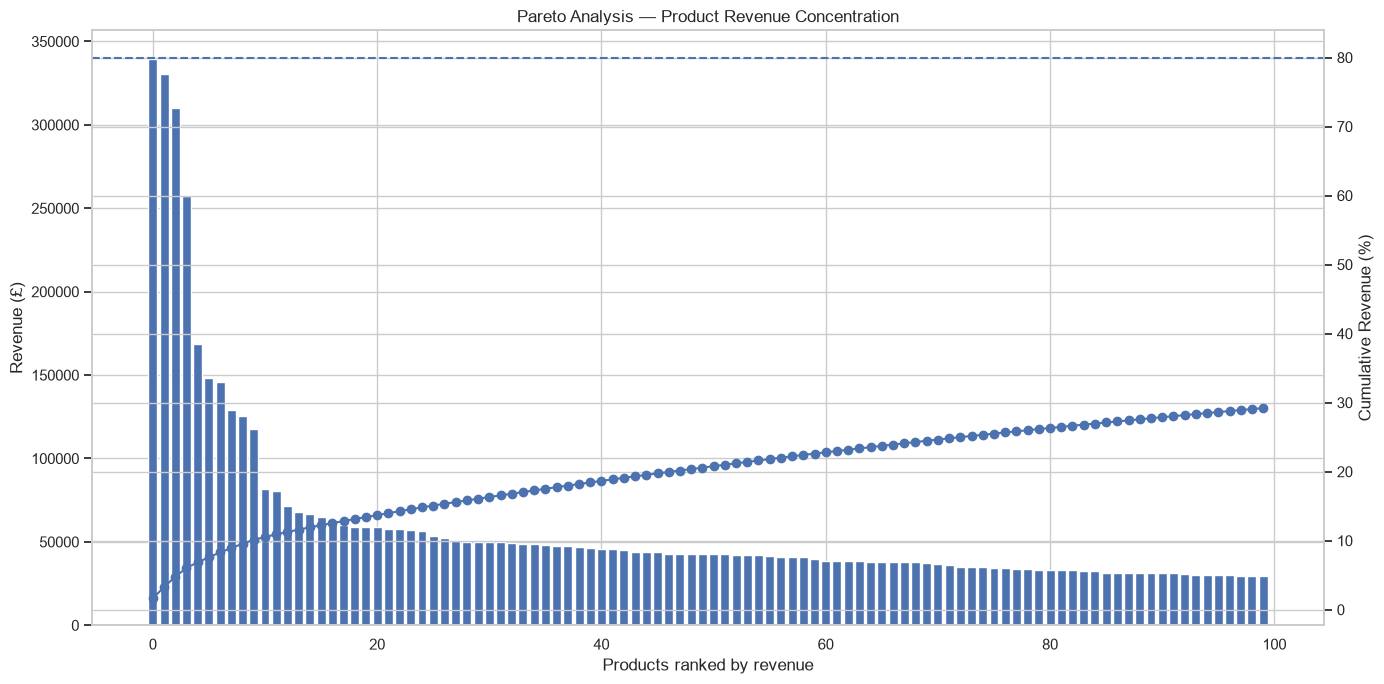

In [19]:
plot_data = pareto_products.head(100)

fig, ax1 = plt.subplots(
    figsize=(14, 7)
)

ax1.bar(
    range(len(plot_data)),
    plot_data["Revenue"]
)

ax1.set_xlabel(
    "Products ranked by revenue"
)

ax1.set_ylabel(
    "Revenue (£)"
)

ax2 = ax1.twinx()

ax2.plot(
    range(len(plot_data)),
    plot_data["CumulativeRevenuePct"],
    marker="o"
)

ax2.axhline(
    80,
    linestyle="--"
)

ax2.set_ylabel(
    "Cumulative Revenue (%)"
)

plt.title(
    "Pareto Analysis — Product Revenue Concentration"
)

plt.tight_layout()
plt.show()

<h2>Product Revenue Lorenz-Style Curve</h2>

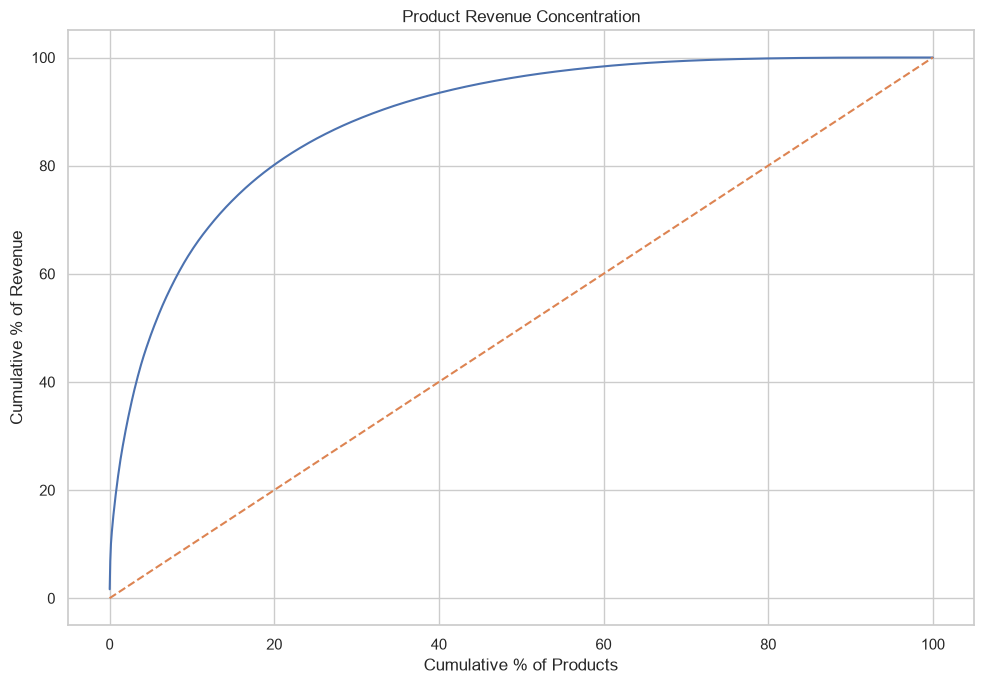

In [20]:
plt.figure(figsize=(10, 7))

plt.plot(
    pareto_products["ProductPct"],
    pareto_products["CumulativeRevenuePct"]
)

plt.plot(
    [0, 100],
    [0, 100],
    linestyle="--"
)

plt.xlabel(
    "Cumulative % of Products"
)

plt.ylabel(
    "Cumulative % of Revenue"
)

plt.title(
    "Product Revenue Concentration"
)

plt.tight_layout()
plt.show()

<h2>Revenue vs Volume Scatterplot</h2>

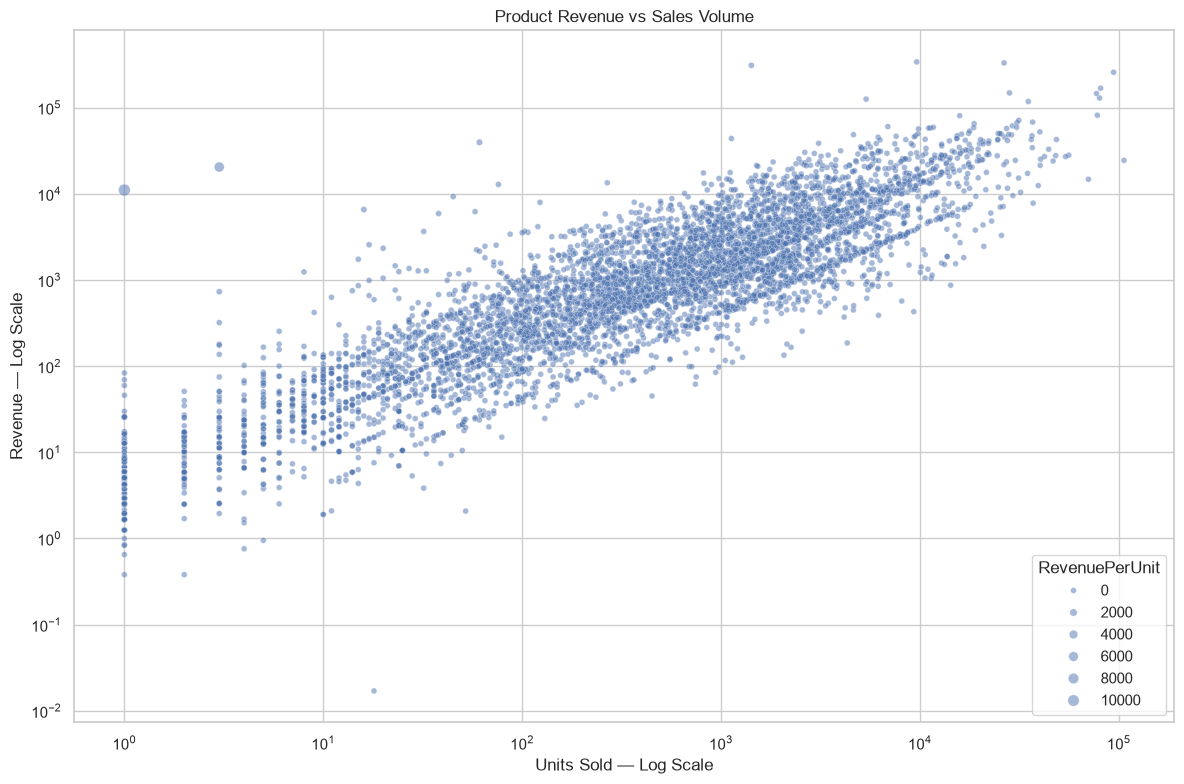

In [21]:
plot_products = product_analysis[
    product_analysis["UnitsSold"] > 0
].copy()

plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=plot_products,
    x="UnitsSold",
    y="Revenue",
    size="RevenuePerUnit",
    alpha=0.5
)

plt.xscale("log")
plt.yscale("log")

plt.title(
    "Product Revenue vs Sales Volume"
)

plt.xlabel("Units Sold — Log Scale")
plt.ylabel("Revenue — Log Scale")

plt.tight_layout()
plt.show()

<h2>Country-Level Analysis</h2>

In [22]:
country_analysis = (
    df.groupby("Country")
    .agg(
        Revenue=("TotalPrice", "sum"),
        UnitsSold=("Quantity", "sum"),
        Orders=("Invoice", "nunique"),
        Customers=("CustomerID", "nunique"),
        AvgUnitPrice=("UnitPrice", "mean")
    )
    .reset_index()
)

country_analysis.head()

,Country,Revenue,UnitsSold,Orders,Customers,AvgUnitPrice
0,Australia,"169,283.46",104067,95,15,3.59
1,Austria,"23,613.01",11578,45,13,4.28
2,Bahrain,"3,109.79",1339,10,2,3.48
3,Belgium,"65,387.82",34778,149,29,4.24
4,Bermuda,"1,253.14",2798,1,0,2.49


<h2>Country AOV</h2>

In [23]:
country_analysis["AOV"] = (
    country_analysis["Revenue"] /
    country_analysis["Orders"]
)

country_analysis.sort_values(
    "AOV",
    ascending=False
).head(20)

,Country,Revenue,UnitsSold,Orders,Customers,AvgUnitPrice,AOV
26,Netherlands,"554,038.09",384519,229,22,2.68,"2,419.38"
33,Singapore,"25,317.06",6994,11,1,39.30,"2,301.55"
0,Australia,"169,283.46",104067,95,15,3.59,"1,781.93"
10,Denmark,"68,580.69",237471,43,12,2.81,"1,594.90"
17,Hong Kong,"23,685.52",7021,15,0,31.31,"1,579.03"
37,Thailand,"3,070.54",2552,2,1,3.00,"1,535.27"
21,Japan,"43,023.91",31643,33,10,2.01,"1,303.75"
4,Bermuda,"1,253.14",2798,1,0,2.49,"1,253.14"
28,Norway,"56,322.50",23623,45,13,15.63,"1,251.61"
31,RSA,"4,804.32",1971,4,2,11.42,"1,201.08"


<h2>Filter Small Countries</h2>

In [24]:
reliable_countries = country_analysis[
    country_analysis["Orders"] >= 50
].copy()

print(
    f"Countries total: "
    f"{len(country_analysis)}"
)

print(
    f"Countries with >= 50 orders: "
    f"{len(reliable_countries)}"
)

Countries total: 43
Countries with >= 50 orders: 14


<h2>Top Countries by Revenue</h2>

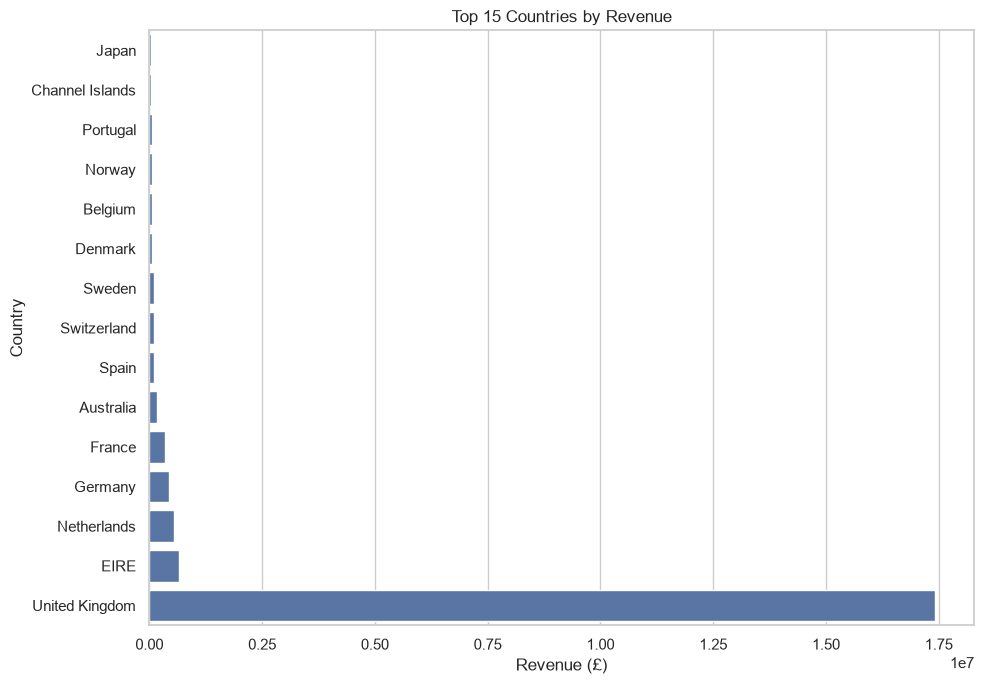

In [25]:
top_country_revenue = (
    country_analysis
    .sort_values(
        "Revenue",
        ascending=False
    )
    .head(15)
    .sort_values("Revenue")
)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_country_revenue,
    x="Revenue",
    y="Country"
)

plt.title(
    "Top 15 Countries by Revenue"
)

plt.xlabel("Revenue (£)")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

<h2>Top Countries by Volume</h2>

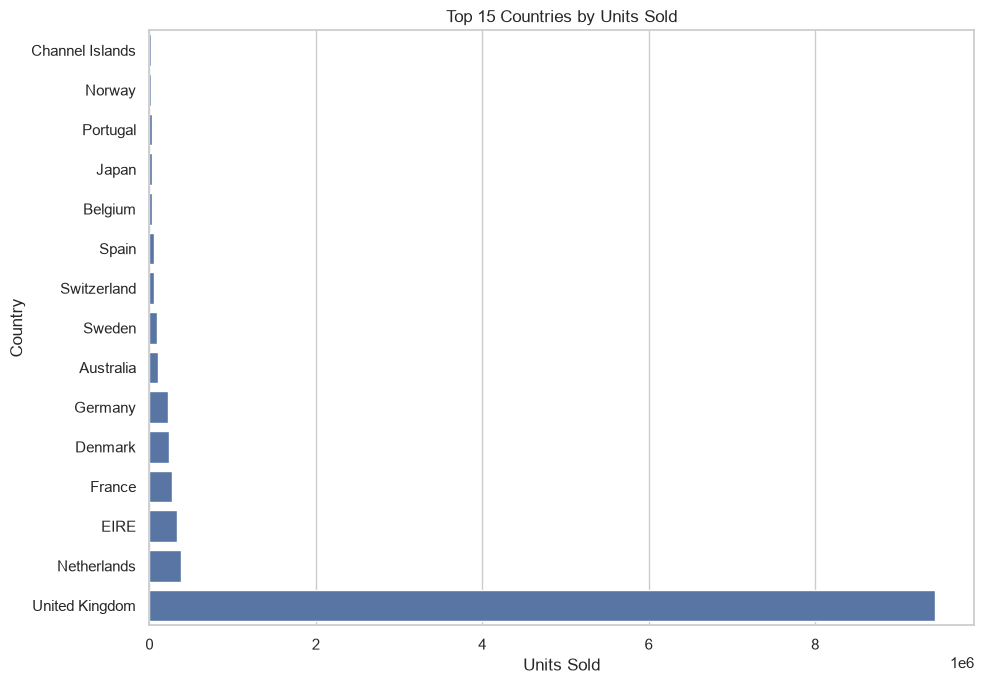

In [26]:
top_country_volume = (
    country_analysis
    .sort_values(
        "UnitsSold",
        ascending=False
    )
    .head(15)
    .sort_values("UnitsSold")
)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_country_volume,
    x="UnitsSold",
    y="Country"
)

plt.title(
    "Top 15 Countries by Units Sold"
)

plt.xlabel("Units Sold")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

<h2>Country Revenue vs Volume</h2>

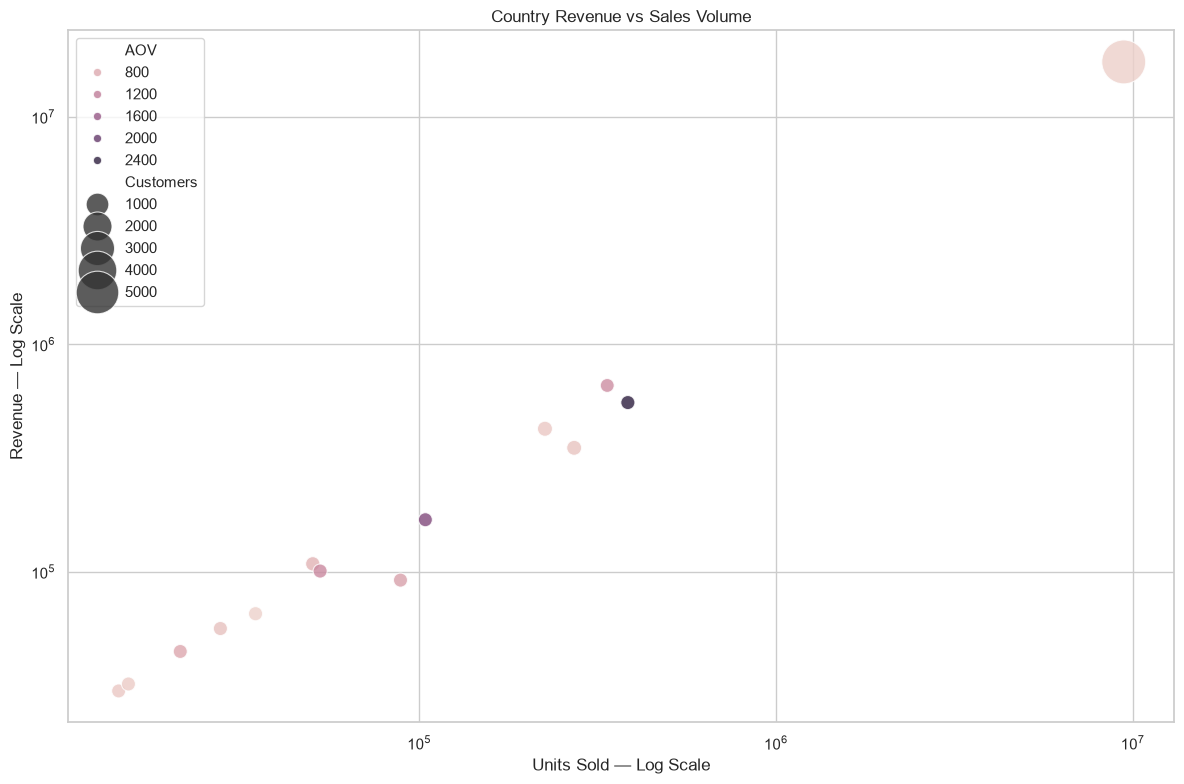

In [27]:
plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=reliable_countries,
    x="UnitsSold",
    y="Revenue",
    size="Customers",
    hue="AOV",
    sizes=(100, 1000),
    alpha=0.8
)

plt.xscale("log")
plt.yscale("log")

plt.title(
    "Country Revenue vs Sales Volume"
)

plt.xlabel("Units Sold — Log Scale")
plt.ylabel("Revenue — Log Scale")

plt.tight_layout()
plt.show()

<h2>Highest AOV Countries</h2>

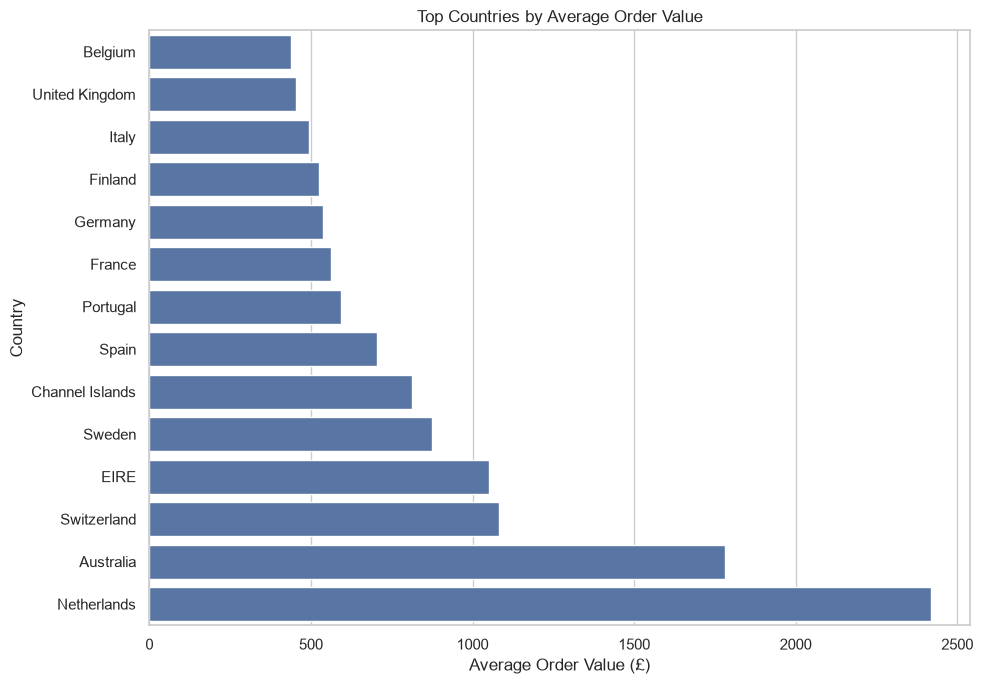

In [28]:
top_aov_countries = (
    reliable_countries
    .sort_values(
        "AOV",
        ascending=False
    )
    .head(15)
    .sort_values("AOV")
)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_aov_countries,
    x="AOV",
    y="Country"
)

plt.title(
    "Top Countries by Average Order Value"
)

plt.xlabel("Average Order Value (£)")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

<h2>Country Revenue Share</h2>

In [29]:
country_analysis["RevenueShare"] = (
    country_analysis["Revenue"] /
    country_analysis["Revenue"].sum() *
    100
)

country_analysis.sort_values(
    "RevenueShare",
    ascending=False
).head(15)

,Country,Revenue,UnitsSold,Orders,Customers,AvgUnitPrice,AOV,RevenueShare
40,United Kingdom,"17,410,569.69",9437245,38399,5353,4.00,453.41,85.03
11,EIRE,"658,767.31",336604,626,5,5.46,"1,052.34",3.22
26,Netherlands,"554,038.09",384519,229,22,2.68,"2,419.38",2.71
15,Germany,"425,019.71",225173,789,107,3.59,538.68,2.08
14,France,"350,456.09",271902,622,95,4.27,563.43,1.71
0,Australia,"169,283.46",104067,95,15,3.59,"1,781.93",0.83
34,Spain,"108,332.49",50318,154,41,4.26,703.46,0.53
36,Switzerland,"100,685.59",52763,93,22,3.75,"1,082.64",0.49
35,Sweden,"91,869.82",88633,105,19,4.91,874.95,0.45
10,Denmark,"68,580.69",237471,43,12,2.81,"1,594.90",0.33


<h2>Country Revenue Concentration</h2>

In [30]:
country_pareto = (
    country_analysis
    .sort_values(
        "Revenue",
        ascending=False
    )
    .reset_index(drop=True)
)

country_pareto["CumulativeRevenue"] = (
    country_pareto["Revenue"]
    .cumsum()
)

country_pareto["CumulativeRevenuePct"] = (
    country_pareto["CumulativeRevenue"] /
    country_pareto["Revenue"].sum() *
    100
)

country_pareto["CountryPct"] = (
    np.arange(
        1,
        len(country_pareto) + 1
    ) /
    len(country_pareto) *
    100
)

In [31]:
countries_for_80pct = country_pareto[
    country_pareto["CumulativeRevenuePct"] <= 80
]

print(
    f"Countries generating first 80% of revenue: "
    f"{len(countries_for_80pct)}"
)

Countries generating first 80% of revenue: 0


<h2>Returns — Product Level</h2>

In [32]:
product_returns = (
    returns_df
    .groupby(
        [
            "StockCode",
            "DescriptionClean"
        ]
    )
    .agg(
        ReturnedUnits=(
            "Quantity",
            lambda x: x.abs().sum()
        ),
        ReturnValue=(
            "ReturnValue",
            "sum"
        ),
        ReturnOrders=(
            "Invoice",
            "nunique"
        )
    )
    .reset_index()
)

product_returns.head()

,StockCode,DescriptionClean,ReturnedUnits,ReturnValue,ReturnOrders
0,10002,INFLATABLE POLITICAL GLOBE,1223,883.55,7
1,10120,DOGGY RUBBER,30,6.30,1
2,10120,ZEBRA INVCING ERROR,9000,0.00,1
3,10123C,HEARTS WRAPPING TAPE,150,12.54,2
4,10123G,ARMY CAMO WRAPPING TAPE,1104,66.24,1


<h2>Merge Sales and Returns</h2>

In [33]:
product_full = product_analysis.merge(
    product_returns,
    on=[
        "StockCode",
        "DescriptionClean"
    ],
    how="left"
)

product_full[
    [
        "ReturnedUnits",
        "ReturnValue",
        "ReturnOrders"
    ]
] = product_full[
    [
        "ReturnedUnits",
        "ReturnValue",
        "ReturnOrders"
    ]
].fillna(0)

<h2>Product Return Rate</h2>
Return Rate =
Returned Units / Units Sold

In [34]:
product_full["ReturnRate"] = (
    product_full["ReturnedUnits"] /
    product_full["UnitsSold"] *
    100
)

product_full["ReturnRate"] = (
    product_full["ReturnRate"]
    .replace(
        [np.inf, -np.inf],
        np.nan
    )
)

<h2>Filter Products with Meaningful Volume</h2>

In [35]:
reliable_products = product_full[
    product_full["UnitsSold"] >= 50
].copy()

print(
    f"Products total: "
    f"{len(product_full):,}"
)

print(
    f"Products with >= 50 units sold: "
    f"{len(reliable_products):,}"
)

Products total: 5,789
Products with >= 50 units sold: 4,555


<h2>Highest Return Rate Products</h2>

In [36]:
highest_return_products = (
    reliable_products
    .sort_values(
        "ReturnRate",
        ascending=False
    )
)

highest_return_products[
    [
        "DescriptionClean",
        "UnitsSold",
        "ReturnedUnits",
        "ReturnRate",
        "ReturnValue"
    ]
].head(20)

,DescriptionClean,UnitsSold,ReturnedUnits,ReturnRate,ReturnValue
5753,DISCOUNT,196,"3,064.00","1,563.27","13,277.52"
425,TREE OF NOAH FESTIVE SCENTED CANDLE,57,96.00,168.42,201.60
3122,WRONGLY CODED 20713,800,"1,000.00",125.00,0.00
4187,BLACK CHERRY LIGHTS,242,248.00,102.48,"1,557.20"
3459,"PAPER CRAFT , LITTLE BIRDIE",80995,"80,995.00",100.00,"168,469.60"
3737,MULTICOLOUR FEATHERS CURTAIN,72,72.00,100.00,236.40
291,LITTLE FLOWER SHOPPER BAG,400,400.00,100.00,424.00
3835,INCORRECTLY CREDITED C550456 SEE 47,1300,"1,300.00",100.00,0.00
879,RED POLKADOT PUDDING BOWL,3717,"3,648.00",98.14,474.24
881,BLUE POLKADOT PUDDING BOWL,2565,"2,496.00",97.31,324.48


<h2>Return Rate Visualization</h2>

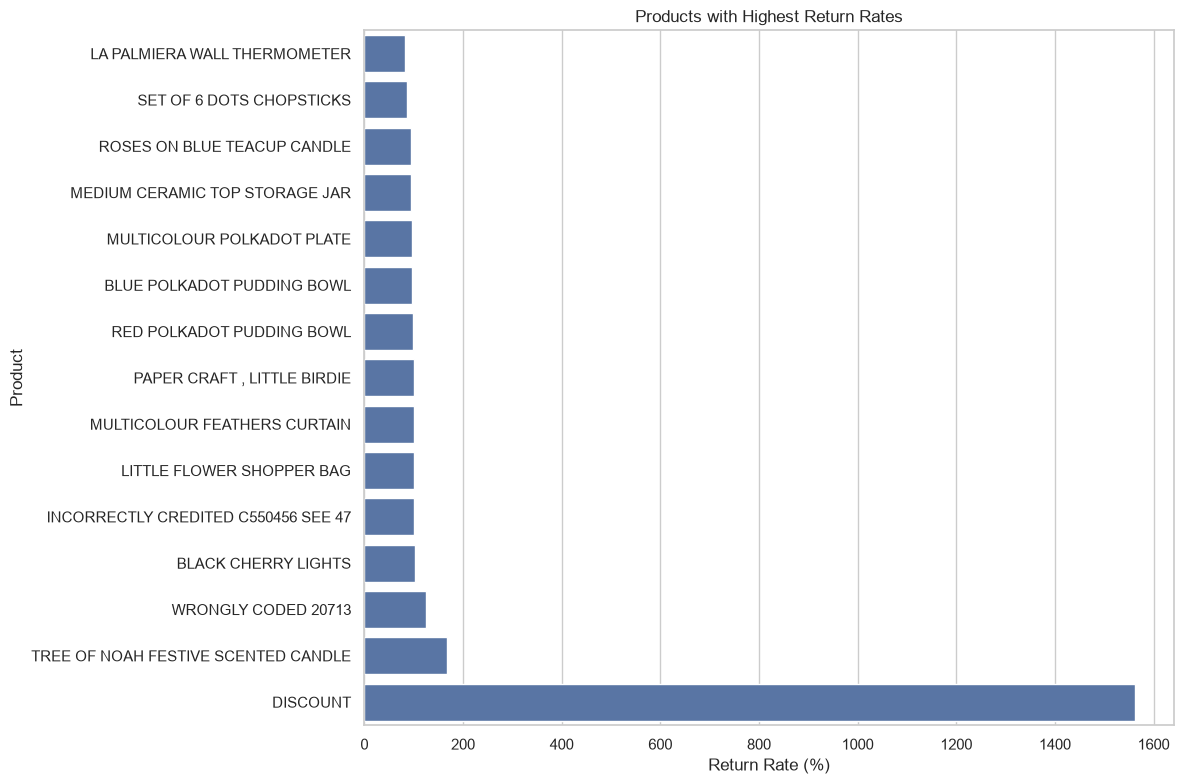

In [37]:
top_return_products = (
    highest_return_products
    .head(15)
    .sort_values("ReturnRate")
)

plt.figure(figsize=(12, 8))

sns.barplot(
    data=top_return_products,
    x="ReturnRate",
    y="DescriptionClean"
)

plt.title(
    "Products with Highest Return Rates"
)

plt.xlabel("Return Rate (%)")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

<h2>Most Returned Products by Units</h2>

In [38]:
most_returned_products = (
    product_full
    .sort_values(
        "ReturnedUnits",
        ascending=False
    )
)

most_returned_products[
    [
        "DescriptionClean",
        "UnitsSold",
        "ReturnedUnits",
        "ReturnRate",
        "ReturnValue"
    ]
].head(20)

,DescriptionClean,UnitsSold,ReturnedUnits,ReturnRate,ReturnValue
3459,"PAPER CRAFT , LITTLE BIRDIE",80995,"80,995.00",100.00,"168,469.60"
2904,MEDIUM CERAMIC TOP STORAGE JAR,78033,"74,494.00",95.46,"77,479.64"
4358,ROTATING SILVER ANGELS T-LIGHT HLDR,31409,"9,381.00",29.87,330.45
582,SET/6 FRUIT SALAD PAPER CUPS,16615,"7,140.00",42.97,572.52
589,SET/6 FRUIT SALAD PAPER PLATES,15919,"7,008.00",44.02,911.04
5773,MANUAL,9637,"5,444.00",56.49,"422,926.14"
52,POP ART PEN CASE & PENS,10612,"5,184.00",48.85,414.72
5131,BLACK SILVER FLOWER T-LIGHT HOLDER,11520,"5,040.00",43.75,387.36
3641,MULTICOLOUR SPRING FLOWER MUG,13665,"4,996.00",36.56,501.22
51,TEATIME PEN CASE & PENS,10056,"4,632.00",46.06,389.04


<h2>Most Returned Products by Financial Value</h2>

In [39]:
most_returned_value = (
    product_full
    .sort_values(
        "ReturnValue",
        ascending=False
    )
)

most_returned_value[
    [
        "DescriptionClean",
        "UnitsSold",
        "ReturnedUnits",
        "ReturnRate",
        "ReturnValue"
    ]
].head(20)

,DescriptionClean,UnitsSold,ReturnedUnits,ReturnRate,ReturnValue
5773,MANUAL,9637,"5,444.00",56.49,"422,926.14"
5749,AMAZON FEE,3,33.00,"1,100.00","241,988.30"
3459,"PAPER CRAFT , LITTLE BIRDIE",80995,"80,995.00",100.00,"168,469.60"
2904,MEDIUM CERAMIC TOP STORAGE JAR,78033,"74,494.00",95.46,"77,479.64"
5751,BANK CHARGES,34,76.00,223.53,"36,001.49"
1948,REGENCY CAKESTAND 3 TIER,26495,"1,450.00",5.47,"16,545.30"
5775,POSTAGE,5363,302.00,5.63,"15,252.01"
5753,DISCOUNT,196,"3,064.00","1,563.27","13,277.52"
5150,WHITE HANGING HEART T-LIGHT HOLDER,94147,"3,637.00",3.86,"9,387.10"
3966,COLOUR GLASS. STAR T-LIGHT HOLDER,14077,"2,520.00",17.90,"6,966.66"


<h2>Country Return Analysis</h2>

In [40]:
country_returns = (
    returns_df
    .groupby("Country")
    .agg(
        ReturnedUnits=(
            "Quantity",
            lambda x: x.abs().sum()
        ),
        ReturnValue=(
            "ReturnValue",
            "sum"
        ),
        ReturnOrders=(
            "Invoice",
            "nunique"
        )
    )
    .reset_index()
)

country_returns.head()

,Country,ReturnedUnits,ReturnValue,ReturnOrders
0,Australia,692,"2,839.04",22
1,Austria,272,435.41,6
2,Bahrain,64,248.24,2
3,Belgium,180,"2,178.93",34
4,Channel Islands,1009,"3,543.15",24


<h2>Merge Country Sales + Returns</h2>

In [41]:
country_full = country_analysis.merge(
    country_returns,
    on="Country",
    how="left"
)

country_full[
    [
        "ReturnedUnits",
        "ReturnValue",
        "ReturnOrders"
    ]
] = country_full[
    [
        "ReturnedUnits",
        "ReturnValue",
        "ReturnOrders"
    ]
].fillna(0)

<h2>Country Return Rate</h2>

In [42]:
country_full["ReturnRate"] = (
    country_full["ReturnedUnits"] /
    country_full["UnitsSold"] *
    100
)

country_full["ReturnValueRate"] = (
    country_full["ReturnValue"] /
    country_full["Revenue"] *
    100
)

<h2>Countries with Highest Return Rates</h2>

In [43]:
reliable_return_countries = country_full[
    country_full["UnitsSold"] >= 1000
].copy()

highest_return_countries = (
    reliable_return_countries
    .sort_values(
        "ReturnRate",
        ascending=False
    )
)

highest_return_countries[
    [
        "Country",
        "UnitsSold",
        "ReturnedUnits",
        "ReturnRate",
        "ReturnValueRate"
    ]
].head(15)

,Country,UnitsSold,ReturnedUnits,ReturnRate,ReturnValueRate
14,France,271902,"90,330.00",33.22,8.20
38,USA,5264,"1,564.00",29.71,24.86
34,Spain,50318,"5,651.00",11.23,15.99
40,United Kingdom,9437245,"923,544.00",9.79,7.27
39,United Arab Emirates,7321,593.00,8.10,10.35
2,Bahrain,1339,64.00,4.78,7.98
21,Japan,31643,"1,505.00",4.76,7.81
7,Channel Islands,21396,"1,009.00",4.72,7.94
29,Poland,5688,184.00,3.23,3.51
11,EIRE,336604,"9,173.00",2.73,7.41


<h2>Country Return Rate Chart</h2>

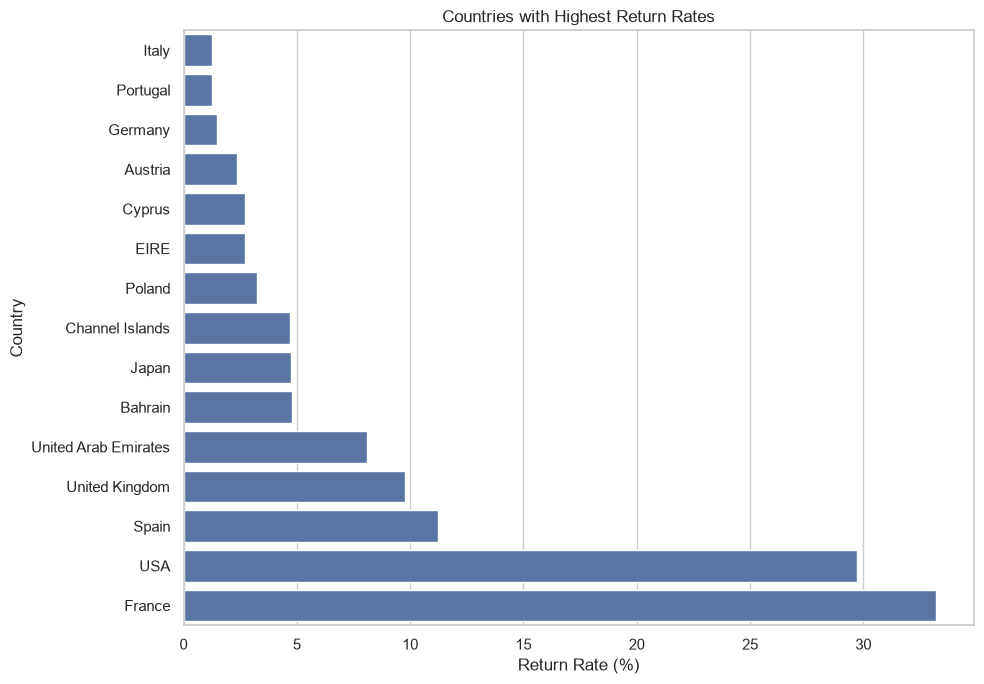

In [44]:
plot_returns = (
    highest_return_countries
    .head(15)
    .sort_values("ReturnRate")
)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=plot_returns,
    x="ReturnRate",
    y="Country"
)

plt.title(
    "Countries with Highest Return Rates"
)

plt.xlabel("Return Rate (%)")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

<h2>Product Return Rate vs Revenue</h2>

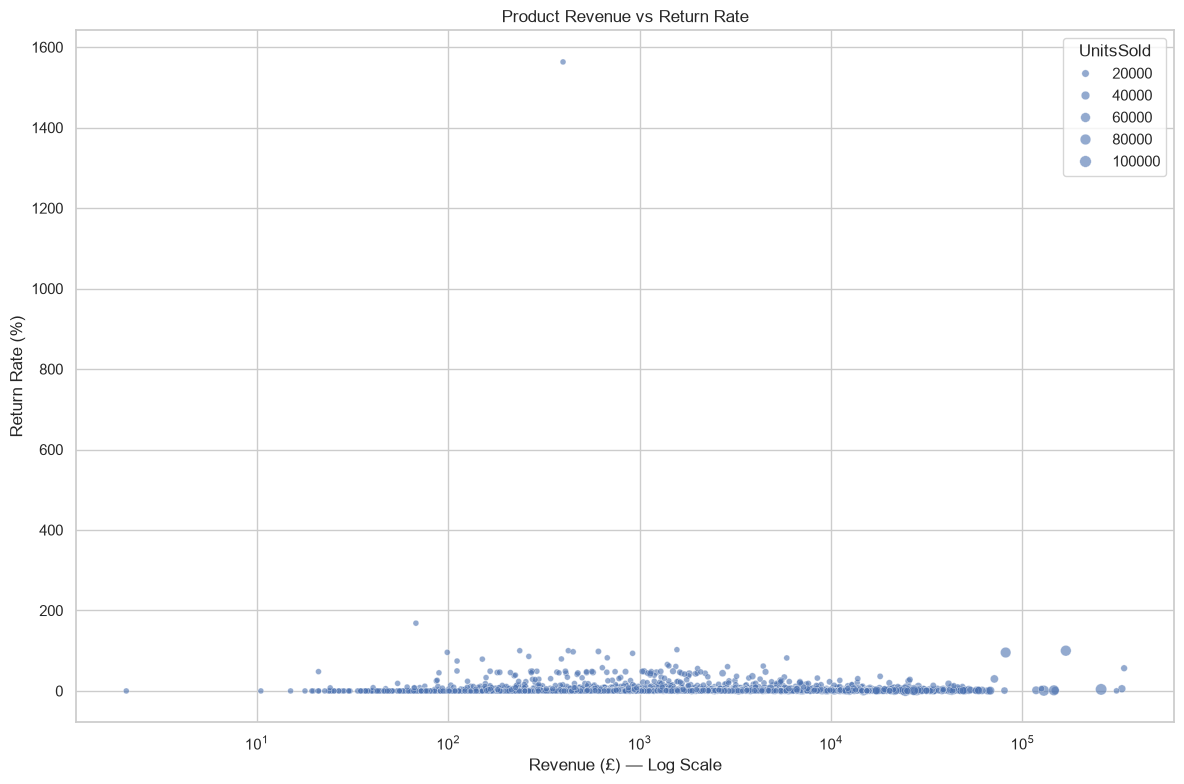

In [45]:
plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=reliable_products,
    x="Revenue",
    y="ReturnRate",
    size="UnitsSold",
    alpha=0.6
)

plt.xscale("log")

plt.title(
    "Product Revenue vs Return Rate"
)

plt.xlabel("Revenue (£) — Log Scale")
plt.ylabel("Return Rate (%)")

plt.tight_layout()
plt.show()

<h2>Identify High-Revenue / High-Return Products</h2>

In [46]:
revenue_threshold = (
    reliable_products["Revenue"].median()
)

return_threshold = (
    reliable_products["ReturnRate"].median()
)

problem_products = reliable_products[
    (
        reliable_products["Revenue"]
        >= revenue_threshold
    )
    &
    (
        reliable_products["ReturnRate"]
        >= return_threshold
    )
].copy()

problem_products = problem_products.sort_values(
    [
        "ReturnRate",
        "Revenue"
    ],
    ascending=False
)

problem_products[
    [
        "DescriptionClean",
        "Revenue",
        "UnitsSold",
        "ReturnRate",
        "ReturnValue"
    ]
].head(20)

,DescriptionClean,Revenue,UnitsSold,ReturnRate,ReturnValue
4187,BLACK CHERRY LIGHTS,"1,565.70",242,102.48,"1,557.20"
3459,"PAPER CRAFT , LITTLE BIRDIE","168,469.60",80995,100.00,"168,469.60"
2904,MEDIUM CERAMIC TOP STORAGE JAR,"81,700.92",78033,95.46,"77,479.64"
2838,PANTRY CHOPPING BOARD,"5,868.50",1154,81.98,"4,803.06"
2766,IVORY CHANDELIER T-LIGHT HOLDER,"1,395.18",657,65.75,690.72
2769,BEADED CHANDELIER T-LIGHT HOLDER,"1,420.97",695,62.30,636.15
4200,WILLOW BRANCH LIGHTS.,"4,423.69",725,61.79,"2,519.60"
4813,BLUE CUSHION COVER WITH FLOWER,"1,545.53",283,60.78,723.40
2768,FLOWERS CHANDELIER T-LIGHT HOLDER,"2,879.37",960,60.31,"1,859.07"
5773,MANUAL,"339,599.81",9637,56.49,"422,926.14"


<h2>Product Revenue Share</h2>

In [47]:
product_full["RevenueShare"] = (
    product_full["Revenue"] /
    product_full["Revenue"].sum() *
    100
)

product_full.sort_values(
    "RevenueShare",
    ascending=False
).head(20)

,StockCode,DescriptionClean,Revenue,UnitsSold,Orders,Customers,AvgUnitPrice,RevenueRank,VolumeRank,RankDifference,RevenuePerUnit,ReturnedUnits,ReturnValue,ReturnOrders,ReturnRate,RevenueShare
5773,M,MANUAL,"339,599.81",9637,791,443,391.06,1.00,244.00,243.00,35.24,"5,444.00","422,926.14",495.00,56.49,1.66
1948,22423,REGENCY CAKESTAND 3 TIER,"330,590.32",26495,3920,1314,14.18,2.00,43.00,41.00,12.48,"1,450.00","16,545.30",341.00,5.47,1.61
5772,DOT,DOTCOM POSTAGE,"309,854.11",1420,1420,1,218.21,3.00,"1,691.00","1,688.00",218.21,3.00,10.01,3.00,0.21,1.51
5150,85123A,WHITE HANGING HEART T-LIGHT HOLDER,"257,546.20",94147,5361,1490,3.07,4.00,2.00,-2.00,2.74,"3,637.00","9,387.10",134.00,3.86,1.26
3459,23843,"PAPER CRAFT , LITTLE BIRDIE","168,469.60",80995,1,1,2.08,5.00,3.00,-2.00,2.08,"80,995.00","168,469.60",1.00,100.00,0.82
3833,47566,PARTY BUNTING,"148,318.28",28217,2676,894,5.71,6.00,35.00,29.00,5.26,285.00,"1,238.55",23.00,1.01,0.72
5117,85099B,JUMBO BAG RED RETROSPOT,"145,961.83",77286,3249,860,2.36,7.00,6.00,-1.00,1.89,"1,191.00","2,127.42",71.00,1.54,0.71
4777,84879,ASSORTED COLOUR BIRD ORNAMENT,"129,324.49",80090,2808,1010,1.86,8.00,4.00,-4.00,1.61,511.00,774.07,19.00,0.64,0.63
5775,POST,POSTAGE,"125,682.42",5363,1851,405,29.47,9.00,501.00,492.00,23.44,302.00,"15,252.01",226.00,5.63,0.61
1525,22086,PAPER CHAIN KIT 50'S CHRISTMAS,"117,760.29",35084,2018,896,3.37,10.00,24.00,14.00,3.36,590.00,"1,461.70",16.00,1.68,0.58


<h2>Country Revenue Share</h2>

In [48]:
country_full["RevenueShare"] = (
    country_full["Revenue"] /
    country_full["Revenue"].sum() *
    100
)

country_full.sort_values(
    "RevenueShare",
    ascending=False
).head(20)

,Country,Revenue,UnitsSold,Orders,Customers,AvgUnitPrice,AOV,RevenueShare,ReturnedUnits,ReturnValue,ReturnOrders,ReturnRate,ReturnValueRate
40,United Kingdom,"17,410,569.69",9437245,38399,5353,4.00,453.41,85.03,"923,544.00","1,265,833.21","10,707.00",9.79,7.27
11,EIRE,"658,767.31",336604,626,5,5.46,"1,052.34",3.22,"9,173.00","48,813.53",180.00,2.73,7.41
26,Netherlands,"554,038.09",384519,229,22,2.68,"2,419.38",2.71,"2,666.00","5,707.39",21.00,0.69,1.03
15,Germany,"425,019.71",225173,789,107,3.59,538.68,2.08,"3,357.00","13,060.55",306.00,1.49,3.07
14,France,"350,456.09",271902,622,95,4.27,563.43,1.71,"90,330.00","28,722.70",124.00,33.22,8.20
0,Australia,"169,283.46",104067,95,15,3.59,"1,781.93",0.83,692.00,"2,839.04",22.00,0.66,1.68
34,Spain,"108,332.49",50318,154,41,4.26,703.46,0.53,"5,651.00","17,319.05",34.00,11.23,15.99
36,Switzerland,"100,685.59",52763,93,22,3.75,"1,082.64",0.49,507.00,"1,282.53",30.00,0.96,1.27
35,Sweden,"91,869.82",88633,105,19,4.91,874.95,0.45,775.00,"4,094.30",24.00,0.87,4.46
10,Denmark,"68,580.69",237471,43,12,2.81,"1,594.90",0.33,"2,707.00","4,121.10",10.00,1.14,6.01


<h2>Build Executive Product Table</h2>

In [49]:
product_executive = (
    product_full[
        [
            "StockCode",
            "DescriptionClean",
            "Revenue",
            "UnitsSold",
            "Orders",
            "Customers",
            "AvgUnitPrice",
            "RevenuePerUnit",
            "ReturnedUnits",
            "ReturnValue",
            "ReturnRate"
        ]
    ]
    .sort_values(
        "Revenue",
        ascending=False
    )
)

product_executive.head(20)

,StockCode,DescriptionClean,Revenue,UnitsSold,Orders,Customers,AvgUnitPrice,RevenuePerUnit,ReturnedUnits,ReturnValue,ReturnRate
5773,M,MANUAL,"339,599.81",9637,791,443,391.06,35.24,"5,444.00","422,926.14",56.49
1948,22423,REGENCY CAKESTAND 3 TIER,"330,590.32",26495,3920,1314,14.18,12.48,"1,450.00","16,545.30",5.47
5772,DOT,DOTCOM POSTAGE,"309,854.11",1420,1420,1,218.21,218.21,3.00,10.01,0.21
5150,85123A,WHITE HANGING HEART T-LIGHT HOLDER,"257,546.20",94147,5361,1490,3.07,2.74,"3,637.00","9,387.10",3.86
3459,23843,"PAPER CRAFT , LITTLE BIRDIE","168,469.60",80995,1,1,2.08,2.08,"80,995.00","168,469.60",100.00
3833,47566,PARTY BUNTING,"148,318.28",28217,2676,894,5.71,5.26,285.00,"1,238.55",1.01
5117,85099B,JUMBO BAG RED RETROSPOT,"145,961.83",77286,3249,860,2.36,1.89,"1,191.00","2,127.42",1.54
4777,84879,ASSORTED COLOUR BIRD ORNAMENT,"129,324.49",80090,2808,1010,1.86,1.61,511.00,774.07,0.64
5775,POST,POSTAGE,"125,682.42",5363,1851,405,29.47,23.44,302.00,"15,252.01",5.63
1525,22086,PAPER CHAIN KIT 50'S CHRISTMAS,"117,760.29",35084,2018,896,3.37,3.36,590.00,"1,461.70",1.68


<h2>Build Executive Country Table</h2>

In [50]:
country_executive = (
    country_full[
        [
            "Country",
            "Revenue",
            "UnitsSold",
            "Orders",
            "Customers",
            "AOV",
            "ReturnedUnits",
            "ReturnValue",
            "ReturnRate",
            "ReturnValueRate"
        ]
    ]
    .sort_values(
        "Revenue",
        ascending=False
    )
)

country_executive.head(20)

,Country,Revenue,UnitsSold,Orders,Customers,AOV,ReturnedUnits,ReturnValue,ReturnRate,ReturnValueRate
40,United Kingdom,"17,410,569.69",9437245,38399,5353,453.41,"923,544.00","1,265,833.21",9.79,7.27
11,EIRE,"658,767.31",336604,626,5,"1,052.34","9,173.00","48,813.53",2.73,7.41
26,Netherlands,"554,038.09",384519,229,22,"2,419.38","2,666.00","5,707.39",0.69,1.03
15,Germany,"425,019.71",225173,789,107,538.68,"3,357.00","13,060.55",1.49,3.07
14,France,"350,456.09",271902,622,95,563.43,"90,330.00","28,722.70",33.22,8.20
0,Australia,"169,283.46",104067,95,15,"1,781.93",692.00,"2,839.04",0.66,1.68
34,Spain,"108,332.49",50318,154,41,703.46,"5,651.00","17,319.05",11.23,15.99
36,Switzerland,"100,685.59",52763,93,22,"1,082.64",507.00,"1,282.53",0.96,1.27
35,Sweden,"91,869.82",88633,105,19,874.95,775.00,"4,094.30",0.87,4.46
10,Denmark,"68,580.69",237471,43,12,"1,594.90","2,707.00","4,121.10",1.14,6.01


<h2>Save Product Analysis</h2>

In [51]:
product_executive.to_csv(
    REPORTS_DIR /
    "product_analysis.csv",
    index=False
)

<h2>Save Country Analysis</h2>

In [52]:
country_executive.to_csv(
    REPORTS_DIR /
    "country_analysis.csv",
    index=False
)

<h2>Save Pareto Analysis</h2>

In [53]:
pareto_products.to_csv(
    REPORTS_DIR /
    "product_pareto_analysis.csv",
    index=False
)

country_pareto.to_csv(
    REPORTS_DIR /
    "country_pareto_analysis.csv",
    index=False
)

<h2>Save Problem Products</h2>

In [54]:
problem_products.to_csv(
    REPORTS_DIR /
    "high_revenue_high_return_products.csv",
    index=False
)

<h2>Final Summary</h2>

In [55]:
top_product = (
    product_full
    .sort_values("Revenue", ascending=False)
    .iloc[0]
)

top_volume_product = (
    product_full
    .sort_values("UnitsSold", ascending=False)
    .iloc[0]
)

top_country = (
    country_full
    .sort_values("Revenue", ascending=False)
    .iloc[0]
)

top_volume_country = (
    country_full
    .sort_values("UnitsSold", ascending=False)
    .iloc[0]
)

print("=" * 70)
print("PRODUCT & COUNTRY ANALYSIS COMPLETE")
print("=" * 70)

print(
    f"\nTop product by revenue:"
    f"\n{top_product['DescriptionClean']}"
    f"\nRevenue: £{top_product['Revenue']:,.2f}"
)

print(
    f"\nTop product by volume:"
    f"\n{top_volume_product['DescriptionClean']}"
    f"\nUnits: {top_volume_product['UnitsSold']:,.0f}"
)

print(
    f"\nTop country by revenue:"
    f"\n{top_country['Country']}"
    f"\nRevenue: £{top_country['Revenue']:,.2f}"
)

print(
    f"\nTop country by volume:"
    f"\n{top_volume_country['Country']}"
    f"\nUnits: {top_volume_country['UnitsSold']:,.0f}"
)

print(
    f"\nProducts generating first 80% of revenue:"
    f"\n{number_products_80:,}"
    f" ({percentage_products_80:.2f}% of products)"
)

print("=" * 70)

PRODUCT & COUNTRY ANALYSIS COMPLETE

Top product by revenue:
MANUAL
Revenue: £339,599.81

Top product by volume:
WORLD WAR 2 GLIDERS ASSTD DESIGNS
Units: 106,250

Top country by revenue:
United Kingdom
Revenue: £17,410,569.69

Top country by volume:
United Kingdom
Units: 9,437,245

Products generating first 80% of revenue:
1,150 (19.87% of products)
